Required Imports.

In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.data import Data
from torch_geometric.loader import LinkNeighborLoader
import networkx as nx
import os
import numpy as np
import pandas as pd
import torch_geometric as torch_g
from torch_geometric.nn import Node2Vec
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from pathlib import Path
import pronto
from pronto import Ontology
import gc
import platform

print(f"--- Environment Versions ---")
print(f"Python:       {platform.python_version()}")
print(f"PyTorch:      {torch.__version__}")
print(f"PyG (PyTorch Geometric): {torch_g.__version__}")
print(f"Pandas:       {pd.__version__}")
print(f"Matplotlib:   {plt.matplotlib.__version__}")
print(f"NetworkX:     {nx.__version__}")
print(f"Scikit-Learn: {sklearn.__version__}")
print(f"Pronto:       {pronto.__version__}")
if torch.cuda.is_available():
    # Get the ID of the current device
    device_id = torch.cuda.current_device()
    
    # Get properties
    props = torch.cuda.get_device_properties(device_id)
    
    # Get memory info (returns bytes, so we convert to GB)
    free_mem, total_mem = torch.cuda.mem_get_info()
    
    print(f"--- GPU Specifications ---")
    print(f"Name:              {props.name}")
    print(f"Compute Capability: {props.major}.{props.minor}")
    print(f"Total VRAM:        {total_mem / 1024**3:.2f} GB")
    print(f"Available VRAM:    {free_mem / 1024**3:.2f} GB")
    print(f"Cores (SMs):       {props.multi_processor_count}")
else:
    print("No CUDA GPU detected.")

--- Environment Versions ---
Python:       3.12.3
PyTorch:      2.5.1+cu121
PyG (PyTorch Geometric): 2.7.0
Pandas:       3.0.0
Matplotlib:   3.10.8
NetworkX:     3.6.1
Scikit-Learn: 1.8.0
Pronto:       2.7.3
--- GPU Specifications ---
Name:              NVIDIA GeForce RTX 3090 Ti
Compute Capability: 8.6
Total VRAM:        23.99 GB
Available VRAM:    22.74 GB
Cores (SMs):       84


**EDA**  
We know so far the following:
- 144 tissues were used to train with the algorithm and 107 leaf tissues were used to test in the Ohmnet study

**Exploring the data files**

*Tissue hierarchy*

In [4]:
data_dir = Path('./data')

pd.read_csv(data_dir / 'tissue.hierarchy', sep='\t', header=None)


,0,1
0,BTO:0001388,BTO:0000203_NODE
1,BTO:0001387,BTO:0000753_NODE
2,BTO:0003099_NODE,BTO:0000083_NODE
3,BTO:0003092_NODE,BTO:0003091_NODE
4,BTO:0003091_NODE,Root_NODE
...,...,...
213,BTO:0002295,BTO:0001515_NODE
214,BTO:0000562,BTO:0000088_NODE
215,BTO:0000620,BTO:0000651_NODE
216,BTO:0000199,BTO:0001369_NODE


BRENDA Tissue Ontology (BTO) file

In [13]:
onto = Ontology(str(data_dir / 'BrendaTissue.obo'))

#Print target tissue ontology
target_ids = ["BTO:0001388", "BTO:0000203"]
for tid in target_ids:
    if tid in onto:
        t = onto[tid]
        print(f"{t.id} -> {t.name}")
    else:
        print(f"{tid} not found in ontology")
target_ids = ["BTO:0001387", "BTO:0000753"]
for tid in target_ids:
    if tid in onto:
        t = onto[tid]
        print(f"{t.id} -> {t.name}")
    else:
        print(f"{tid} not found in ontology")
print("\n")
with open(data_dir / 'BrendaTissue.obo', 'r', encoding='utf-8') as f:
    for i in range(20):
        print(f.readline().strip())

BTO:0001388 -> trachea
BTO:0000203 -> respiratory system
BTO:0001387 -> tonsil
BTO:0000753 -> lymphoid tissue


format-version: 1.2
date: 03:05:2016 09:39
saved-by: Marion, contact@brenda-enzymes.org
auto-generated-by: OBO-Edit 2.3.1
synonymtypedef: GE "LANGUAGE GERMAN"
synonymtypedef: SCI "SCIENTIFIC NAME"
default-namespace: BrendaTissueOBO
remark: www.brenda-enzymes.org

[Term]
id: BTO:0000000
name: tissues, cell types and enzyme sources
def: "A structured controlled vocabulary for the source of an enzyme. It comprises terms of tissues, cell lines, cell types and cell cultures from uni- and multicellular organisms." [curators:mgr]

[Term]
id: BTO:0000001
name: culture condition:-induced cell
is_a: BTO:0000216 ! culture condition

[Term]


*Vizualizing tissue.edges file*

In [29]:
pd.read_csv(data_dir / 'tissue.edges', sep='\t', header=None) #seems to simply be a name representation of tissue.hierarchy without the BTO

,0,1
0,Trachea,RespiratorySystem
1,Tonsil,LymphoidTissue
2,InternalFemaleGenitalOrgan,FemaleReproductiveSystem
3,UrinarySystem,UrogenitalSystem
4,UrogenitalSystem,Root
...,...,...
213,Podocyte,GlomerularEpithelium
214,Heart,CardiovascularSystem
215,Ileum,SmallIntestine
216,CardiacMuscle,VertebrateMuscularSystem


*Vizualizing PPT-Ohmnet_tissues-combined.edgelist*

In [5]:
df_PPI = pd.read_csv(data_dir / 'PPT-Ohmnet_tissues-combined.edgelist', sep='\t') #Contains 3666563 PPIs and their respective tissue from the 144 tissues of the Ohmnet study
df_PPI #noticing the tissues like "urinary_bladder" might need formatting to match BTO nomenclature

,# protein1,protein2,tissue
0,4790,79155,urinary_bladder
1,26039,6597,urinary_bladder
2,57154,3309,urinary_bladder
3,6631,9775,urinary_bladder
4,1855,8312,urinary_bladder
...,...,...,...
3666558,6045,1153,spermatocyte
3666559,10616,1387,spermatocyte
3666560,2033,7026,spermatocyte
3666561,324,1457,spermatocyte


*Unique tissues*

In [6]:
unique_tissues = df_PPI['tissue'].unique() #here are the 144 tissues used for training in the Ohmnet study, the 107 leaf tissues will need to be isolated on the basis of the parent-children relationship
print(unique_tissues)

<StringArray>
[                'urinary_bladder',                    'hypothalamus',
                           'colon', 'umbilical_vein_endothelial_cell',
                           'brain',                          'tonsil',
                  'nervous_system',                       'forebrain',
                        'placenta',                          'neuron',
 ...
                         'oviduct',         'hematopoietic_stem_cell',
                      'cerebellum',                     'bone_marrow',
                        'bronchus',                 'skin_fibroblast',
                 'skeletal_muscle',       'vascular_endothelial_cell',
                          'muscle',                    'spermatocyte']
Length: 144, dtype: str


*Clear the memory*

In [44]:
del unique_tissues
del df_PPI
gc.collect()

1843

**The plan is as follows:**  

1. Load the tissue.hierarchy file using networkx and use it to build a directed graph
2. Sort the tissue graph into a list of NodeView object for indexing
3. Index the tissues for reproducibility and easy edge list creation
4. Create the edge list of indexed tuples using the indexed NodeView object with source and destination
5. Transform the python list into a tensor and make it contiguous in memory for faster training
6. Create node2vec model with:
    - 256 embeddings to start (there are 219 tissues so I want to allow sufficient "mathematical space", 128 might be too small and 512 might be too inefficient)
    - walk length=20 -> the number of hops the model will do
    - context_size=10 -> how many nodes the model looks at at every node, 10 is probably too high given the way the tissues are organized
    - walks_per_node=10 -> model simulates 10 walks per node
    - num_negative_samples=1 -> for each connected node pair, sample 1 negative node pair to see what not to learn
    - p=1, q=1 -> unbiased in terms of p: high p = move away, low p: stay near origin; high q: walk samples neighborhood, low q: walk explores long paths (depth-first search type)
    - sparse=True -> since a lot of the tissues are not connected, this will lead to sparse fewer calculations because only a few tissues' embeddings are being updated each step; makes it much faster and uses less memory
    - num_nodes=len(tissue_nodes) -> tell the model how many nodes thre are
7. Initialize the embeddings to a xavier_normal_ distribution (introduced after troubleshooting the observation of astronomical losses and that model didn't train well)
8. put the model on GPU (already defined 'device' to be device agnostic)
9. define a dataloader to create batches of walks, define an optimizer, determine a number of epochs
10. define a training loop to train the model -> I deliberately delete the positive and negative random walks to save memory
11. print results

*Load Tissue Hierarchy for construction of tissue graph to train on the entire tissue hierarchy.*

In [5]:
tissue_graph = nx.read_edgelist(data_dir / 'tissue.hierarchy', create_using=nx.DiGraph())
tissue_nodes = sorted(list(tissue_graph.nodes()))

node_to_idx_tissue = {}
for idx, node in enumerate(tissue_nodes):
    node_to_idx_tissue[node] = idx

edges_tissue = []
for src, dst in tissue_graph.edges():
    src_index = node_to_idx_tissue[src]
    dst_index = node_to_idx_tissue[dst]
    edges_tissue.append((src_index, dst_index)) 
print(f"edges format: {edges_tissue}")

edges_index_tissue = torch.tensor(edges_tissue, dtype=torch.long).t().contiguous()

print(f"Shape of edges_index_tissue: {edges_index_tissue.shape}")
print(f"Number of tissues: {len(tissue_nodes)}")

#edges_index_tissue shape is ([2,218]) so we have 218 and len(tissue_nodes) is 219 meaning we have 219 tissue nodes

edges format: [(172, 34), (34, 218), (171, 106), (106, 218), (211, 9), (9, 7), (209, 208), (208, 218), (210, 8), (8, 7), (88, 126), (126, 218), (195, 70), (70, 33), (117, 68), (68, 218), (194, 94), (94, 76), (160, 106), (116, 29), (29, 167), (40, 185), (185, 218), (196, 67), (67, 22), (139, 211), (140, 16), (16, 191), (138, 42), (42, 100), (192, 65), (65, 93), (33, 218), (35, 187), (187, 218), (200, 121), (121, 183), (201, 52), (52, 71), (72, 31), (31, 49), (71, 43), (43, 45), (6, 190), (190, 218), (142, 218), (143, 106), (183, 26), (120, 86), (86, 84), (119, 105), (105, 86), (47, 212), (212, 199), (161, 76), (76, 218), (46, 35), (147, 158), (158, 152), (64, 93), (93, 218), (150, 70), (163, 22), (22, 34), (30, 101), (101, 94), (107, 100), (100, 28), (108, 56), (56, 189), (49, 0), (0, 218), (188, 68), (186, 218), (134, 95), (95, 56), (214, 175), (175, 61), (166, 54), (54, 26), (165, 80), (80, 9), (167, 218), (168, 186), (28, 26), (26, 40), (25, 187), (24, 68), (27, 44), (44, 185), (110,

*Generating embeddings for tissue hierarchy*

In [6]:
node2vec_engine = Node2Vec(
    edges_index_tissue,
    embedding_dim=256,
    walk_length=20,
    context_size=10,
    walks_per_node=10,
    num_negative_samples=1,
    p=1, q=1,
    sparse=True,
    num_nodes=len(tissue_nodes) # Explicitly pass num_nodes
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.nn.init.xavier_normal_(node2vec_engine.embedding.weight)
node2vec_engine = node2vec_engine.to(device)

print("Training Node2Vec embeddings...")
loader = node2vec_engine.loader(batch_size=32, shuffle=True, num_workers=0)
optimizer_n2v = torch.optim.SparseAdam(list(node2vec_engine.parameters()), lr=0.01)

node2vec_epochs = 1000
for epoch in range(1, node2vec_epochs + 1):
    node2vec_engine.train()
    total_loss = 0
    for pos_rw, neg_rw in loader:
        optimizer_n2v.zero_grad()
        loss_n2v = node2vec_engine.loss(pos_rw.to(device), neg_rw.to(device))
        loss_n2v.backward()
        optimizer_n2v.step()
        total_loss += loss_n2v.item()
        
        # --- Memory Management ---
        del pos_rw, neg_rw, loss_n2v
            
    if epoch % 100 == 0:
        print(f"  Node2Vec Epoch: {epoch:03d}, Loss: {total_loss / len(loader):.4f}")
print("Node2Vec training complete.")

Training Node2Vec embeddings...
  Node2Vec Epoch: 100, Loss: 0.7690
  Node2Vec Epoch: 200, Loss: 0.7549
  Node2Vec Epoch: 300, Loss: 0.7509
  Node2Vec Epoch: 400, Loss: 0.7493
  Node2Vec Epoch: 500, Loss: 0.7509
  Node2Vec Epoch: 600, Loss: 0.7494
  Node2Vec Epoch: 700, Loss: 0.7499
  Node2Vec Epoch: 800, Loss: 0.7452
  Node2Vec Epoch: 900, Loss: 0.7475
  Node2Vec Epoch: 1000, Loss: 0.7485
Node2Vec training complete.


*Saving embeddings*

In [36]:
node2vec_engine = node2vec_engine.to('cpu')

embeddings = node2vec_engine.embedding.weight.data

torch.save(node2vec_engine.state_dict(), 'node2vec_model.pth')

print("Embeddings saved successfully to node2vec_model.pth")

Embeddings saved successfully to node2vec_model.pth


*Load embeddings*

In [25]:
# Re-initialize the model shell with the EXACT same parameters
node2vec_engine = Node2Vec(
    edges_index_tissue,
    embedding_dim=256,
    walk_length=20,
    context_size=10,
    walks_per_node=10,
    num_negative_samples=1,
    p=1, q=1,
    sparse=True,
    num_nodes=len(tissue_nodes)
)

# Load the state dictionary from the file
state_dict = torch.load('node2vec_model.pth')

# Apply the state dictionary to your new model
node2vec_engine.load_state_dict(state_dict)

# Set it to evaluation mode (if you are done training)
node2vec_engine.eval()

print("Model loaded successfully!")


Model loaded successfully!


C:\Users\steve\AppData\Local\Temp\ipykernel_2572\3846122681.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('node2vec_model.pth')


**Next Steps**  
1. Put the model on CPU if it's on GPU
2. Extract the raw embeddings from the model
3. Make Root_NODE the root of the tree as in, use its embeddings as the root embeddings
4. Set Root_NODE as the root of the tree
5. Setup the data pipeline from the PPI and map the tissues to the embeddings
6. Map tissue names to BTO by stripping the file
7. Map processed tissue names to their unique hierarchy indices.
8. Group PPI records by protein pairs to create a multi-label target matrix.
9. Split the interaction data into training, validation, and test sets.
10. Instantiate graph loaders for spatial neighborhood sampling.
11. Define the LateFusionGAT architecture and hierarchical penalty loss.
12. Train the model and evaluate performance using ROCAUC and F1 scores.

*Taking the raw weights from the embeddings and set Root_NODE as the root node of the tree*

In [7]:
node2vec_engine = node2vec_engine.to('cpu') #if save model cell is not run we still need to move the model to CPU

tissue_embeddings_raw = node2vec_engine.embedding.weight.data

if 'Root_NODE' in node_to_idx_tissue:
    root_node_idx = node_to_idx_tissue['Root_NODE']
    global_tissue_address = tissue_embeddings_raw[root_node_idx].unsqueeze(0)
else:
    global_tissue_address = tissue_embeddings_raw.mean(dim=0, keepdim=True)
global_tissue_address = global_tissue_address.to('cuda' if torch.cuda.is_available() else 'cpu')

*Setting up the data pipeline from the 3.6M PPI file*

In [8]:
print("Setting up data pipeline...")
ppi_file_path = data_dir / 'PPT-Ohmnet_tissues-combined.edgelist'
df = pd.read_csv(ppi_file_path, sep='\t', header=0, names=['protein_a', 'protein_b', 'tissue'])

unique_proteins = pd.concat([df['protein_a'], df['protein_b']]).unique()
protein_to_idx = {prot: i for i, prot in enumerate(unique_proteins)}
num_unique_proteins = len(unique_proteins)

# Use the same 'tissue_nodes' list from Node2Vec setup for consistency
num_tissues = len(tissue_nodes)

df['p1_idx'] = df['protein_a'].map(protein_to_idx)
df['p2_idx'] = df['protein_b'].map(protein_to_idx)

Setting up data pipeline...


*BTO mapping begins here: strip id and name from file and build a searchable dictionary*

In [9]:
print("Building Name-to-BTO mapping from BrendaTissue.obo...")
obo_path = data_dir / 'BrendaTissue.obo'
name_to_bto = {}
if obo_path.exists():
    with open(obo_path, 'r', encoding='utf-8') as f:
        cid = None
        for line in f:
            line = line.strip()
            if line.startswith('id: '): cid = line[4:]
            elif line.startswith('name: ') and cid: name_to_bto[line[6:].lower()] = cid

Building Name-to-BTO mapping from BrendaTissue.obo...


*Problem discovered in function to map BTO tissues to dataset -> I was losing 70k PPIs and manually setting those to find the proper tissues*  
I found the IDs by inspecting the obo file and the PPI dataset and noticed dicrepancies in the naming of the tissues in both files.

In [10]:
manual_rescue = {
    'culture condition cd8 cell': 'BTO:0004410',
    'b lymphocyte': 'BTO:0000776',  # UPDATED ID
    'b lymphocytes': 'BTO:0000776', # UPDATED ID
    't lymphocyte': 'BTO:0000782',  # UPDATED ID
    't lymphocytes': 'BTO:0000782'  # UPDATED ID
}


*Function to reformat the tissue names in the PPI dataset to the BTO names then search both manual rescue and the name:BTO_id dictionary for matches*

In [11]:
def map_tissue(t_name):
    # Normalize: 'urinary_bladder' -> 'urinary bladder'
    search_name = str(t_name).lower().replace('_', ' ')
    
    # Check Manual Rescue
    if search_name in manual_rescue:
        bto_id = manual_rescue[search_name]
    else:
        bto_id = name_to_bto.get(search_name)
    
    if not bto_id:
        return None
    
    # Map to Hierarchy Index
    if bto_id in node_to_idx_tissue:
        return node_to_idx_tissue[bto_id]
    if bto_id + '_NODE' in node_to_idx_tissue:
        return node_to_idx_tissue[bto_id + '_NODE']
    
    return None

*Map dataset tissues to tissue_idx from Node2Vec*

In [12]:
print("Setting up data pipeline and mapping indices...")
ppi_file_path = data_dir / 'PPT-Ohmnet_tissues-combined.edgelist'
# 1. Load the raw data
df = pd.read_csv(ppi_file_path, sep='\t', header=0, names=['protein_a', 'protein_b', 'tissue'])
# 2. Map PROTEINS to indices (This creates the missing 'p1_idx' and 'p2_idx')
unique_proteins = pd.concat([df['protein_a'], df['protein_b']]).unique()
protein_to_idx = {prot: i for i, prot in enumerate(unique_proteins)}
num_unique_proteins = len(unique_proteins)
df['p1_idx'] = df['protein_a'].map(protein_to_idx)
df['p2_idx'] = df['protein_b'].map(protein_to_idx)
# 3. Map TISSUES to indices
df['t_idx'] = df['tissue'].map(map_tissue)
# 4. Filter out any unmapped records
original_len = len(df)
df = df.dropna(subset=['t_idx', 'p1_idx', 'p2_idx']).copy()
df['t_idx'] = df['t_idx'].astype(int)
# 5. Summary
new_mapped_count = len(df)
print(f"Mapped {new_mapped_count}/{original_len} PPI records successfully.")

Setting up data pipeline and mapping indices...
Mapped 3666563/3666563 PPI records successfully.


*Protein-Protein-Tissues grouping to collapse 3.6M rows 70.3k rows*

In [13]:
# Group by protein pair and collect all tissues they interact in
grouped = df.groupby(['p1_idx', 'p2_idx'])['t_idx'].apply(list).reset_index()
# Create edge index for PyTorch
source_nodes_all = torch.tensor(grouped['p1_idx'].values, dtype=torch.long)
target_nodes_all = torch.tensor(grouped['p2_idx'].values, dtype=torch.long)
edge_index_all_ppi = torch.stack([source_nodes_all, target_nodes_all], dim=0)
# Create the Multi-Hot target matrix
# (Ensure num_tissues is defined, usually 219)
y_targets_all_ppi = torch.zeros((len(grouped), num_tissues), dtype=torch.float)
for row_idx, tissues in enumerate(grouped['t_idx']):
    y_targets_all_ppi[row_idx, tissues] = 1.0
protein_indices_all = torch.arange(num_unique_proteins, dtype=torch.long)
print(f"Grouped shape: {grouped.shape}")
print(f"Number of unique protein interactions: {len(grouped)}")

Grouped shape: (70338, 3)
Number of unique protein interactions: 70338


*Consolidating PPI Network into PyTorch Geometric Data Object*

In [14]:
full_graph_data = Data(
    x=protein_indices_all,
    edge_index=edge_index_all_ppi # Full PPI graph structure for sampling
)

*Train-Val-Test split: 80% for training, 10% for validation and 10% for testing*

In [15]:
num_unique_ppis = len(grouped)
all_indices = torch.arange(num_unique_ppis, dtype=torch.long)

train_indices, test_val_indices = train_test_split(all_indices, test_size=0.2, random_state=42)
val_indices, test_indices = train_test_split(test_val_indices, test_size=0.5, random_state=42) # 0.5 of 20% = 10%

print(f"Total unique PPIs: {num_unique_ppis}")
print(f"Train PPIs: {len(train_indices)}")
print(f"Validation PPIs: {len(val_indices)}")
print(f"Test PPIs: {len(test_indices)}")

Total unique PPIs: 70338
Train PPIs: 56270
Validation PPIs: 7034
Test PPIs: 7034


*Identifying the leaf nodes used for inference*

In [16]:
leaf_node_names = [node for node in tissue_graph.nodes() if tissue_graph.in_degree(node) == 0 and node != 'Root_NODE']
leaf_node_indices = torch.tensor([node_to_idx_tissue[name] for name in leaf_node_names if name in node_to_idx_tissue], dtype=torch.long)
print(f"Identified {len(leaf_node_indices)} leaf nodes for test set masking.")

Identified 107 leaf nodes for test set masking.


*Instantiating the data_loaders*

In [17]:
train_loader = LinkNeighborLoader(
    full_graph_data,
    num_neighbors=[15, 10],
    batch_size=1024,
    edge_label_index=edge_index_all_ppi[:, train_indices], # Only sample edges from training split
    edge_label=y_targets_all_ppi[train_indices],           # Corresponding labels
    shuffle=True,
)

val_loader = LinkNeighborLoader(
    full_graph_data,
    num_neighbors=[15, 10],
    batch_size=1024, # Can use a larger batch size for validation if VRAM allows
    edge_label_index=edge_index_all_ppi[:, val_indices],
    edge_label=y_targets_all_ppi[val_indices],
    shuffle=False,
)

test_loader = LinkNeighborLoader(
    full_graph_data,
    num_neighbors=[15, 10],
    batch_size=1024,
    edge_label_index=edge_index_all_ppi[:, test_indices],
    edge_label=y_targets_all_ppi[test_indices],
    shuffle=False,
)
print("Train, Validation, Test loaders ready.")

Train, Validation, Test loaders ready.


*Prepare Hierarchical Pairs for customLoss Function.*

In [18]:
hierarchical_pairs_list = []
for child_name, parent_name in tissue_graph.edges():
    child_idx = node_to_idx_tissue[child_name]
    parent_idx = node_to_idx_tissue[parent_name]
    hierarchical_pairs_list.append((child_idx, parent_idx))
hierarchical_pairs = torch.tensor(hierarchical_pairs_list, dtype=torch.long)

*Define the loss function for tissue embeddings*

In [19]:
def custom_loss(y_hat, y_true, hierarchical_pairs_tensor, lambda_penalty=0.1):
    bce_loss = F.binary_cross_entropy(y_hat, y_true)
    
    children_probs = y_hat[:, hierarchical_pairs_tensor[:, 0]]
    parents_probs = y_hat[:, hierarchical_pairs_tensor[:, 1]]
    
    # We use mean() instead of sum() to make penalty independent of batch size
    violations = torch.clamp(children_probs - parents_probs, min=0.0)
    penalty = lambda_penalty * torch.mean(violations)
    
    return bce_loss + penalty

*Defining the late fusion GAT*

In [20]:
class LateFusionGAT(nn.Module):
    def __init__(self, num_proteins, protein_embedding_dim,
                 num_heads, gat_hidden_channels, gat_output_channels,
                 tissue_address_dim, mlp_hidden_channels, num_tissues,
                 global_tissue_address_tensor, dropout_rate=0.3):
        super(LateFusionGAT, self).__init__()

        self.protein_embedding = nn.Embedding(num_proteins, protein_embedding_dim)

        self.gat1 = GATConv(
            in_channels=protein_embedding_dim,
            out_channels=gat_hidden_channels,
            heads=num_heads,
            dropout=dropout_rate,
            add_self_loops=True,
            negative_slope=0.2
        )
        self.gat2 = GATConv(
            in_channels=gat_hidden_channels * num_heads,
            out_channels=gat_output_channels,
            heads=1,
            dropout=dropout_rate,
            add_self_loops=True
        )
        
        self.global_tissue_address = nn.Parameter(global_tissue_address_tensor, requires_grad=False)
        
        mlp_input_dim = (gat_output_channels * 2) + tissue_address_dim

        self.mlp = nn.Sequential(
            nn.Linear(mlp_input_dim, mlp_hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(mlp_hidden_channels, mlp_hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(mlp_hidden_channels // 2, num_tissues)
        )

    def forward(self, batch):
        x = batch.x
        edge_index = batch.edge_index
        
        protein_a_indices = batch.edge_label_index[0]
        protein_b_indices = batch.edge_label_index[1]

        x_embedded = self.protein_embedding(x)

        x_gat = F.elu(self.gat1(x_embedded, edge_index))
        x_gat = self.gat2(x_gat, edge_index)

        # Directly index using the remapped edge_label_index
        emb_protein_a = x_gat[protein_a_indices]
        emb_protein_b = x_gat[protein_b_indices]

        batch_size = emb_protein_a.shape[0]
        repeated_tissue_address = self.global_tissue_address.repeat(batch_size, 1)

        concatenated_features = torch.cat(
            (emb_protein_a, emb_protein_b, repeated_tissue_address),
            dim=-1
        )

        raw_predictions = self.mlp(concatenated_features)
        probabilities = torch.sigmoid(raw_predictions)
        
        return probabilities

**Training, Validation and Testing Plan:**  
1. define architectural hyperparameters
2. Instantiate the model
3. Instantiate the optimizer
4. Define the number of epochs and because we plan to use early stopping, define patience and initialize early_stop_counter to 0
5. Elaborate the training loop:
    - Set model to train, initialize a training loss accumulator
    - Inside for loop (training):
        - send batch to device
        - call optimizer.zero_grad()
        - generate predictions with model(batch)
        - calculate loss using custom loss function with predictions, the tissue labels from the batch, the corresponding hierarchical pair and the penalty for hierarchy violation
        - call loss.backward(), optimizer.step() and add calculated loss to total_train_loss, report avg loss
    - Inside for loop (validation):
        - model.eval(), total_val_loss init, initialize empty predictions and labels lists
        - with torch.no_grad(), for loop calculating losses and appending predictions and labels to previous lists
        - avg loss reporting
        - Calculate metrics on validation set and report (help was needed for calculations)
        - save best_model, checkpoints every 50 epochs
6. Testing:
    - load best model, put model in eval mode
    - get ROCAUC on all tissues and ROCAUC on 107 leaf tissues (comparator)

*Structural hyperparameters and model definition*  (to load model later)

In [21]:
protein_embedding_dim = 256
num_heads = 16
gat_hidden_channels = 256
gat_output_channels = 256
tissue_address_dim = global_tissue_address.shape[1]
mlp_hidden_channels = 1024
dropout_rate = 0.3

model = LateFusionGAT(
    num_proteins=num_unique_proteins,
    protein_embedding_dim=protein_embedding_dim,
    num_heads=num_heads,
    gat_hidden_channels=gat_hidden_channels,
    gat_output_channels=gat_output_channels,
    tissue_address_dim=tissue_address_dim,
    mlp_hidden_channels=mlp_hidden_channels,
    num_tissues=num_tissues, # Use the consistent num_tissues from Node2Vec setup
    global_tissue_address_tensor=global_tissue_address,
    dropout_rate=dropout_rate
).to(device)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- Training and Validation Loop ---
num_epochs = 1000
patience = 50
early_stop_counter = 0
best_val_loss = float('inf')

history_train_loss = []
history_val_loss = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    for i, batch in enumerate(train_loader):
        batch = batch.to(device)
        optimizer.zero_grad()
        
        predictions = model(batch)
        loss = custom_loss(predictions, batch.edge_label, hierarchical_pairs.to(device), lambda_penalty=0.1)
        
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
            
    avg_train_loss = total_train_loss / len(train_loader)
    history_train_loss.append(avg_train_loss)
    print(f"\nEpoch {epoch+1} finished. Avg Train Loss: {avg_train_loss:.4f}")

    # --- Validation Loop ---
    model.eval()
    total_val_loss = 0
    all_val_preds = []
    all_val_labels = []

    with torch.no_grad():
        for i, batch in enumerate(val_loader):
            batch = batch.to(device)
            predictions = model(batch)
            loss = custom_loss(predictions, batch.edge_label, hierarchical_pairs.to(device), lambda_penalty=0.1)
            total_val_loss += loss.item()

            all_val_preds.append(predictions.cpu())
            all_val_labels.append(batch.edge_label.cpu())
    avg_val_loss = total_val_loss / len(val_loader)
    history_val_loss.append(avg_val_loss)
    print(f"  Validation Loss: {avg_val_loss:.4f}")

    # Concatenate all predictions and labels for metric calculation
    all_val_preds = torch.cat(all_val_preds, dim=0)
    all_val_labels = torch.cat(all_val_labels, dim=0)

    #Validation metrics -> ROCAUC, ROCPRC and Macro-F1 (non-weighted avg F1-scores of all the tissues)
    val_roc_auc = []
    y_true_np = all_val_labels.numpy(); y_pred_np = all_val_preds.numpy()
    # Compute metrics on CPU with NumPy for stability
    y_true_np = all_val_labels.numpy()
    y_pred_np = all_val_preds.numpy()
    val_roc_prc = []
    val_f1 = []

    for j in range(num_tissues): #I needed help with this to properly calculate the metrics
        # Evaluate only if both positive and negative classes are present
        if y_true_np[:, j].sum() > 0 and (1.0 - y_true_np[:, j]).sum() > 0:
            try:
                val_roc_auc.append(roc_auc_score(y_true_np[:, j], y_pred_np[:, j]))
                val_roc_prc.append(average_precision_score(y_true_np[:, j], y_pred_np[:, j]))
                # For F1, you typically need to binarize predictions. Let's use a common threshold of 0.5 for now.
                val_f1.append(f1_score(y_true_np[:, j], (y_pred_np[:, j] > 0.5).astype(float)))
            except ValueError:
                pass
    
    avg_val_roc_auc = sum(val_roc_auc) / len(val_roc_auc) if val_roc_auc else 0
    avg_val_roc_prc = sum(val_roc_prc) / len(val_roc_prc) if val_roc_prc else 0
    avg_val_f1 = sum(val_f1) / len(val_f1) if val_f1 else 0

    print(f"  Validation ROCAUC: {avg_val_roc_auc:.4f}, ROCPRC: {avg_val_roc_prc:.4f}, Macro-F1: {avg_val_f1:.4f}")

    # Save best model based on validation loss or ROCAUC
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0 # Reset counter
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': best_val_loss
        }, 'best_model.pt')
        print("  >>> New best model checkpoint saved!")
    else:
        early_stop_counter += 1
        
    # Regular checkpointing every 50 epochs
    if (epoch + 1) % 50 == 0:
        os.makedirs('checkpoints', exist_ok=True)
        checkpoint_path = f'checkpoints/checkpoint_epoch_{epoch+1}.pt'
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': avg_val_loss
        }, checkpoint_path)
        print(f"  Saved epoch checkpoint to {checkpoint_path}")
    if early_stop_counter >= patience:
        print(f'Early stopping triggered after {epoch+1} epochs.')
        break


Epoch 1 finished. Avg Train Loss: 0.4047
  Validation Loss: 0.3708
  Validation ROCAUC: 0.6281, ROCPRC: 0.4546, Macro-F1: 0.2778
  >>> New best model checkpoint saved!

Epoch 2 finished. Avg Train Loss: 0.3699
  Validation Loss: 0.3574
  Validation ROCAUC: 0.6752, ROCPRC: 0.4956, Macro-F1: 0.3149
  >>> New best model checkpoint saved!

Epoch 3 finished. Avg Train Loss: 0.3597
  Validation Loss: 0.3466
  Validation ROCAUC: 0.7070, ROCPRC: 0.5214, Macro-F1: 0.3527
  >>> New best model checkpoint saved!

Epoch 4 finished. Avg Train Loss: 0.3498
  Validation Loss: 0.3408
  Validation ROCAUC: 0.7167, ROCPRC: 0.5297, Macro-F1: 0.3658
  >>> New best model checkpoint saved!

Epoch 5 finished. Avg Train Loss: 0.3451
  Validation Loss: 0.3358
  Validation ROCAUC: 0.7366, ROCPRC: 0.5478, Macro-F1: 0.3932
  >>> New best model checkpoint saved!

Epoch 6 finished. Avg Train Loss: 0.3409
  Validation Loss: 0.3346
  Validation ROCAUC: 0.7494, ROCPRC: 0.5609, Macro-F1: 0.4202
  >>> New best model chec

**Plotting losses**

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(history_train_loss) + 1), history_train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(history_val_loss) + 1), history_val_loss, label='Validation Loss', color='orange')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

*Loading the best model*

In [23]:
model_path = 'best_model.pt'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
checkpoint = torch.load(model_path, weights_only=False, map_location=device)

model = LateFusionGAT(
    num_proteins=num_unique_proteins,
    protein_embedding_dim=protein_embedding_dim,
    num_heads=num_heads,
    gat_hidden_channels=gat_hidden_channels,
    gat_output_channels=gat_output_channels,
    tissue_address_dim=tissue_address_dim,
    mlp_hidden_channels=mlp_hidden_channels,
    num_tissues=num_tissues, 
    global_tissue_address_tensor=global_tissue_address,
    dropout_rate=dropout_rate
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])

model.eval()

best_epoch = checkpoint['epoch']
best_val_loss = checkpoint['val_loss']
print(f"--- Model Loaded Successfully ---")
print(f"Best Epoch: {best_epoch + 1}")
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Model is now in .eval() mode and ready for inference.")

--- Model Loaded Successfully ---
Best Epoch: 829
Best Validation Loss: 0.1130
Model is now in .eval() mode and ready for inference.


In [24]:
example_batch = next(iter(test_loader)).to(device)
model.eval()

with torch.no_grad():
    preds = model(example_batch)
    leaf_predictions = preds[0, leaf_node_indices].cpu().numpy()
    
    max_prob = leaf_predictions.max()
    count_near_max = (leaf_predictions >= (max_prob - 0.05)).sum()
    print(f"--- Leaf Node Predictions (Only 107 tissues) ---")
    print(f"Number of Leaf Tissues tracked: {len(leaf_predictions)}")
    print(f"Max Leaf probability found:     {max_prob:.4f}")
    print(f"Leaf tissues within 0.05 of max: {count_near_max}")

--- Leaf Node Predictions (Only 107 tissues) ---
Number of Leaf Tissues tracked: 107
Max Leaf probability found:     0.9970
Leaf tissues within 0.05 of max: 5


### Direct Comparison: Predictions vs. Labels

In [25]:
with torch.no_grad():
    preds = model(example_batch)
    
    # Get labels for the first interaction in the batch
    labels = example_batch.edge_label[0, leaf_node_indices].cpu().numpy()
    leaf_predictions = preds[0, leaf_node_indices].cpu().numpy()
    # Find the tissues where the model is MOST confident (> 0.5)
    predicted_tissues = np.where(leaf_predictions > 0.5)[0]
    
    # Find the tissues where the label is ACTUALLY "True" (1.0)
    true_tissues = np.where(labels > 0.5)[0]
    print(f"Model predicted {len(predicted_tissues)} tissues.")
    print(f"Actual labels have {len(true_tissues)} tissues.")
    
    # Check the overlap
    correct = np.intersect1d(predicted_tissues, true_tissues)
    print(f"Correctly predicted: {len(correct)}")
    print(f"False Positives:    {len(predicted_tissues) - len(correct)}")
    print(f"Missing (False Neg): {len(true_tissues) - len(correct)}")

Model predicted 10 tissues.
Actual labels have 8 tissues.
Correctly predicted: 8
False Positives:    2
Missing (False Neg): 0


### Deep Dive: Ubiquitous Interaction Analysis (Index 10)

In [26]:
interaction_idx = 10 
with torch.no_grad():
    # 1. Run the model on the existing example_batch
    preds = model(example_batch)
    
    # 2. Isolate labels and predictions for ONLY the leaf nodes for the chosen index
    labels = example_batch.edge_label[interaction_idx, leaf_node_indices].cpu().numpy()
    leaf_predictions = preds[interaction_idx, leaf_node_indices].cpu().numpy()
    # 3. Threshold the data (Confidence > 0.5)
    predicted_tissues = np.where(leaf_predictions > 0.5)[0]
    true_tissues = np.where(labels > 0.2)[0]
    # 4. Report Results
    print(f"--- Analysis for Interaction Index: {interaction_idx} ---")
    print(f"Model predicted {len(predicted_tissues)} tissues.")
    print(f"Actual labels have {len(true_tissues)} tissues.")
    
    # Calculate performance metrics for this specific pair
    correct = np.intersect1d(predicted_tissues, true_tissues)
    fp_indices = np.setdiff1d(predicted_tissues, true_tissues) # Predicted but not in labels
    fn_indices = np.setdiff1d(true_tissues, predicted_tissues) # In labels but model missed
    print(f"Correctly predicted: {len(correct)}")
    print(f"False Positives:    {len(fp_indices)}")
    print(f"Missing (False Neg): {len(fn_indices)}")
    # 5. Biological specific names (Optional)
    if len(fp_indices) > 0 or len(fn_indices) > 0:
        print("\n--- Tissue Discrepancies ---")
        if len(fp_indices) > 0:
            fp_names = [tissue_nodes[leaf_node_indices[i]] for i in fp_indices]
            print(f"Model confidently predicted but label was absent: {fp_names}")
        if len(fn_indices) > 0:
            fn_names = [tissue_nodes[leaf_node_indices[i]] for i in fn_indices]
            print(f"Model missed these labeled tissues: {fn_names}")

--- Analysis for Interaction Index: 10 ---
Model predicted 28 tissues.
Actual labels have 81 tissues.
Correctly predicted: 27
False Positives:    1
Missing (False Neg): 54

--- Tissue Discrepancies ---
Model confidently predicted but label was absent: ['BTO:0001415']
Model missed these labeled tissues: ['BTO:0001388', 'BTO:0000830', 'BTO:0001073', 'BTO:0001862', 'BTO:0001868', 'BTO:0001175', 'BTO:0001340', 'BTO:0001487', 'BTO:0001365', 'BTO:0000776', 'BTO:0002922', 'BTO:0000958', 'BTO:0000959', 'BTO:0000484', 'BTO:0001274', 'BTO:0000938', 'BTO:0001408', 'BTO:0000286', 'BTO:0001239', 'BTO:0001422', 'BTO:0000084', 'BTO:0000530', 'BTO:0002496', 'BTO:0001001', 'BTO:0000573', 'BTO:0000615', 'BTO:0000614', 'BTO:0002042', 'BTO:0000397', 'BTO:0000801', 'BTO:0000211', 'BTO:0000212', 'BTO:0000475', 'BTO:0000045', 'BTO:0000041', 'BTO:0000043', 'BTO:0000887', 'BTO:0001101', 'BTO:0000292', 'BTO:0000980', 'BTO:0001379', 'BTO:0000135', 'BTO:0001260', 'BTO:0000907', 'BTO:0001418', 'BTO:0000099', 'BTO:

### Raw Probabilities Analysis for Missed Tissues

In [27]:
if len(fn_indices) > 0:
    print("--- Raw Probabilities of missed tissues ---")
    for i in fn_indices[:5]:
        prob = leaf_predictions[i]
        name = tissue_nodes[leaf_node_indices[i]]
        print(f"{name}: {prob:.8f}") # Printing to 8 decimal places

--- Raw Probabilities of missed tissues ---
BTO:0001388: 0.31669694
BTO:0000830: 0.14112113
BTO:0001073: 0.36337546
BTO:0001862: 0.11390310
BTO:0001868: 0.17420284


### Threshold Sensitivity & Ranking Performance

In [28]:
for threshold in [0.8, 0.5, 0.3, 0.1]:
    # Calculate predictions at this strictness level
    preds_at_thresh = (leaf_predictions > threshold).sum()
    correct_at_thresh = ((leaf_predictions > threshold) & (labels > 0.5)).sum()
    
    print(f"Threshold {threshold:.1f}: Predicted {preds_at_thresh} tissues | Hit {correct_at_thresh} correct ones.")

Threshold 0.8: Predicted 6 tissues | Hit 6 correct ones.
Threshold 0.5: Predicted 28 tissues | Hit 27 correct ones.
Threshold 0.3: Predicted 53 tissues | Hit 46 correct ones.
Threshold 0.1: Predicted 95 tissues | Hit 75 correct ones.


**Testing**

In [29]:
# --- Test Loop (After training is complete) ---
print("\n--- Starting Final Test Evaluation ---")
checkpoint = torch.load('best_model.pt', weights_only=True)
model.load_state_dict(checkpoint['model_state_dict']) # Load the best model
model.eval()
total_test_loss = 0
all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        batch = batch.to(device)
        predictions = model(batch)
        loss = custom_loss(predictions, batch.edge_label, hierarchical_pairs.to(device), lambda_penalty=0.1)
        total_test_loss += loss.item()

        all_test_preds.append(predictions.cpu())
        all_test_labels.append(batch.edge_label.cpu())
        
avg_test_loss = total_test_loss / len(test_loader)
print(f"  Test Loss: {avg_test_loss:.4f}")

all_test_preds = torch.cat(all_test_preds, dim=0)
all_test_labels = torch.cat(all_test_labels, dim=0)


--- Starting Final Test Evaluation ---
  Test Loss: 0.5466


**Final metrics to see if goal was achieved**

In [30]:
# --- Final Test Metrics ---
y_true_test = all_test_labels.numpy()
y_pred_test = all_test_preds.numpy()

# Metrics for ALL tissues
all_roc_auc = [roc_auc_score(y_true_test[:, j], y_pred_test[:, j]) for j in range(num_tissues) if y_true_test[:, j].sum() > 0 and (1.0 - y_true_test[:, j]).sum() > 0]
print(f'  Final Test ROCAUC (All 144 Tissues): {sum(all_roc_auc)/len(all_roc_auc):.4f}')

# Metrics for LEAF tissues (Goal target)
# Select only the predictions and labels for the 107 leaf nodes
test_preds_leaf = all_test_preds[:, leaf_node_indices].numpy()
test_labels_leaf = all_test_labels[:, leaf_node_indices].numpy()
test_roc_auc = []
for j in range(len(leaf_node_indices)):
    if test_labels_leaf[:, j].sum() > 0 and (1.0 - test_labels_leaf[:, j]).sum() > 0:
        try:
            test_roc_auc.append(roc_auc_score(test_labels_leaf[:, j], test_preds_leaf[:, j]))
        except: pass
avg_test_roc_auc = sum(test_roc_auc) / len(test_roc_auc) if test_roc_auc else 0
print(f'  Final Test ROCAUC (107 Leaf Tissues): {avg_test_roc_auc:.4f}')
target_roc_auc = 0.756
if avg_test_roc_auc > target_roc_auc:
    print(f"  Goal Achieved! Test ROCAUC ({avg_test_roc_auc:.4f}) exceeded target ({target_roc_auc:.4f}).")
else:
    print(f"  Goal Not Met. Test ROCAUC ({avg_test_roc_auc:.4f}) is below target ({target_roc_auc:.4f}).")

  Final Test ROCAUC (All 144 Tissues): 0.9514
  Final Test ROCAUC (107 Leaf Tissues): 0.9485
  Goal Achieved! Test ROCAUC (0.9485) exceeded target (0.7560).


**Goal achieved, on to other metrics**

*Defining a neighborhood attention analyzer*

Analyzing the most connected protein: 4914


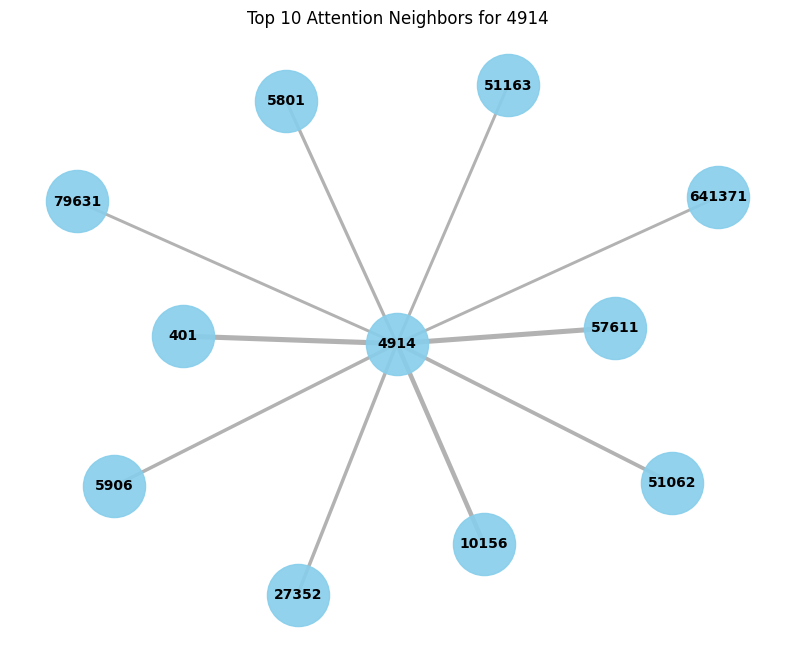

In [32]:
idx_to_protein = {v: k for k, v in protein_to_idx.items()}
def analyze_and_plot_attention(model, data, target_protein_name, top_k=10):
    model.eval()
    
    # 1. Get the Index for the target protein
    p_idx = protein_to_idx.get(target_protein_name)
    if p_idx is None:
        print(f"Protein {target_protein_name} not found in index.")
        return
    
    with torch.no_grad():
        # 2. Correct input: Embed the proteins first!
        x_embedded = model.protein_embedding(data.x.to(device))
        
        # 3. Call GAT1 and capture attention weights
        # out is the features, weights is a tuple: (edge_index_with_self_loops, alpha)
        _, (edge_index_attn, alpha) = model.gat1(
            x_embedded, 
            data.edge_index.to(device), 
            return_attention_weights=True
        )
        
        # 4. Average attention across all 16 heads
        # alpha shape is [num_edges, num_heads]
        alpha_avg = alpha.mean(dim=-1).cpu().numpy()
        edge_index_attn = edge_index_attn.cpu().numpy()
        
        # 5. Filter for edges connected to our target protein
        mask = (edge_index_attn[0] == p_idx) | (edge_index_attn[1] == p_idx)
        relevant_edges = edge_index_attn[:, mask]
        relevant_weights = alpha_avg[mask]
        
        # 6. Sort and pick top K neighbors by attention weight
        sort_idx = np.argsort(relevant_weights)[::-1][:top_k]
        
        # 7. Build the NetworkX Graph for Visualization
        G = nx.Graph()
        for i in sort_idx:
            u, v = relevant_edges[0, i], relevant_edges[1, i]
            weight = relevant_weights[i]
            
            # Use protein names for nodes
            u_name = idx_to_protein.get(u, f"ID:{u}")
            v_name = idx_to_protein.get(v, f"ID:{v}")
            
            G.add_edge(u_name, v_name, weight=weight)
        # 8. Plotting
        plt.figure(figsize=(10, 8))
        pos = nx.spring_layout(G, k=0.5) # Space out nodes
        
        # Draw nodes
        nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='skyblue', alpha=0.9)
        nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
        
        # Draw edges with thickness based on attention weight
        weights = [G[u][v]['weight'] * 20 for u, v in G.edges()] # Scale for visibility
        nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.6)
        
        plt.title(f"Top {top_k} Attention Neighbors for {target_protein_name}")
        plt.axis('off')
        plt.show()
# --- HOW TO RUN ---
# 1. Find the protein with the most connections in your index
top_hub_name = max(protein_to_idx.keys(), key=lambda name: (full_graph_data.edge_index[0] == protein_to_idx[name]).sum())
print(f"Analyzing the most connected protein: {top_hub_name}")
# 2. Run the attention analysis
analyze_and_plot_attention(model, full_graph_data, target_protein_name=top_hub_name, top_k=10)

### Numerical Attention Weights for Hub Protein 4914

In [34]:
# 1. Map the string name "4914" to its internal index
target_idx = protein_to_idx.get("4914")

if target_idx is None:
    # If it's already an integer in your dictionary, try directly
    target_idx = protein_to_idx.get(int("4914"))

if target_idx is None:
    print(f"Error: Protein '4914' is not in the protein_to_idx mapping!")
else:
    with torch.no_grad():
        x_embedded = model.protein_embedding(full_graph_data.x.to(device))
        _, (edge_index_attn, alpha) = model.gat1(
            x_embedded, 
            full_graph_data.edge_index.to(device), 
            return_attention_weights=True
        )
        
        alpha_avg = alpha.mean(dim=-1).cpu().numpy()
        edge_index_attn = edge_index_attn.cpu().numpy()
        
        # 2. Check for the internal target_idx!
        mask = (edge_index_attn[0] == target_idx) | (edge_index_attn[1] == target_idx)
        relevant_edges = edge_index_attn[:, mask]
        relevant_weights = alpha_avg[mask]
        
        # 3. Handle Hub Filtering
        sort_idx = np.argsort(relevant_weights)[::-1]

        print(f"--- Top 15 Attention Neighbors for Protein '4914' (internal index: {target_idx}) ---")
        print(f"{'Neighbor Name':<15} | {'Attention Weight':<18}")
        for i in sort_idx[:15]:
            u, v = relevant_edges[0, i], relevant_edges[1, i]
            neighbor_id = v if u == target_idx else u
            neighbor_name = idx_to_protein.get(neighbor_id, str(neighbor_id))
            print(f"{neighbor_name:<15} | {relevant_weights[i]:.6f}")

        print(f"Total neighbors analyzed: {len(relevant_weights)}")

--- Top 15 Attention Neighbors for Protein '4914' (internal index: 3369) ---
Neighbor Name   | Attention Weight  
401             | 0.184828
57611           | 0.182196
10156           | 0.163610
51062           | 0.137548
27352           | 0.125677
5906            | 0.125324
5801            | 0.116619
51163           | 0.107974
79631           | 0.106903
641371          | 0.105398
57026           | 0.094081
8408            | 0.087347
51170           | 0.078906
23376           | 0.073882
10818           | 0.073193
Total neighbors analyzed: 786


### Biological Validation: Functional Co-occurrence

In [ ]:
hub_id = 4914
top_neighbor_id = 401 

hub_rows = df[(df['protein_a'] == hub_id) | (df['protein_b'] == hub_id)]
hub_tissues = set(hub_rows['tissue'].unique())

neighbor_rows = df[(df['protein_a'] == top_neighbor_id) | (df['protein_b'] == top_neighbor_id)]
neighbor_tissues = set(neighbor_rows['tissue'].unique())

# Find the Intersection (The tissues they share)
shared_tissues = hub_tissues.intersection(neighbor_tissues)

# Report Results
print(f"--- Biological Validation for Hub {hub_id} and Neighbor {top_neighbor_id} ---")
print(f"Hub '{hub_id}' is found in {len(hub_tissues)} tissues.")
print(f"Neighbor '{top_neighbor_id}' is found in {len(neighbor_tissues)} tissues.")
print(f"Total Shared Tissues (Interaction Locations): {len(shared_tissues)}")

# Sample of Shared Tissues
if len(shared_tissues) > 0:
    print(f"\nExample of Shared Tissues: {list(shared_tissues)[:10]}")

--- Biological Validation for Hub 4914 and Neighbor 401 ---
Hub '4914' is found in 3 tissues.
Neighbor '401' is found in 4 tissues.
Total Shared Tissues (Interaction Locations): 1

Example of Shared Tissues: ['nervous_system']


### Biological Validation: Functional Co-occurrence

In [ ]:
# List of top neighbor IDs from the previous output
top_neighbors = [401, 57611, 10156, 51062, 27352]
hub_id = 4914

# Get Hub Tissues once
hub_tissues = set(df[(df['protein_a'] == hub_id) | (df['protein_b'] == hub_id)]['tissue'].unique())

print(f"Analyzing Top 5 Attention Neighbors for Hub {hub_id} (Tissues: {hub_tissues})\n")

for n_id in top_neighbors:
    n_tissues = set(df[(df['protein_a'] == n_id) | (df['protein_b'] == n_id)]['tissue'].unique())
    shared = hub_tissues.intersection(n_tissues)
    
    print(f"Neighbor {n_id}:")
    print(f"  - Unique Tissues: {len(n_tissues)}")
    print(f"  - SHARED with Hub: {shared if shared else 'None'}")
    print("-" * 30)

Analyzing Top 5 Attention Neighbors for Hub 4914 (Tissues: {'hematopoietic_stem_cell', 'blood', 'nervous_system'})

Neighbor 401:
  - Unique Tissues: 4
  - SHARED with Hub: {'nervous_system'}
------------------------------
Neighbor 57611:
  - Unique Tissues: 1
  - SHARED with Hub: {'nervous_system'}
------------------------------
Neighbor 10156:
  - Unique Tissues: 95
  - SHARED with Hub: {'hematopoietic_stem_cell', 'blood', 'nervous_system'}
------------------------------
Neighbor 51062:
  - Unique Tissues: 1
  - SHARED with Hub: {'nervous_system'}
------------------------------
Neighbor 27352:
  - Unique Tissues: 118
  - SHARED with Hub: {'hematopoietic_stem_cell', 'blood', 'nervous_system'}
------------------------------
